# 01 — Clinical EDA

Initial exploration of the Diabetes 130-US Hospitals dataset. Objectives:

1. Confirm dataset shape and variable types
2. Map missing values (including `?`, the missing-value code used in this dataset)
3. Distribution of the readmission outcome
4. Demographic and clinical distributions
5. First clinical hypotheses to guide feature engineering


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Visual config
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)

# Path to raw data folder (one level up, since we are inside notebooks/)
RAW = Path("../data/raw")
print("Files in raw/:", [f.name for f in RAW.iterdir() if not f.name.startswith(".")])


Files in raw/: ['IDS_mapping.csv', 'diabetic_data.csv']


In [2]:
# Load main dataset. Pass na_values="?" because this dataset encodes
# missing values as the literal string "?" — without this, pandas
# would treat it as a valid category and silently mask the problem.
df = pd.read_csv(RAW / "diabetic_data.csv", na_values="?")

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 101,766 rows × 50 columns


/var/folders/3d/b6tlh05n7mj440lzzc7_nh0w0000gp/T/ipykernel_93617/1704680930.py:4: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(RAW / "diabetic_data.csv", na_values="?")


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
# Comprehensive overview: dtype, missingness, cardinality per column.
# This single table tells us where to focus cleaning effort.
overview = pd.DataFrame({
    "dtype": df.dtypes,
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
})

# Sort by missingness, descending — worst offenders at the top.
overview.sort_values("pct_missing", ascending=False).head(20)

,dtype,n_missing,pct_missing,n_unique
weight,str,98569,96.86,9
max_glu_serum,str,96420,94.75,3
A1Cresult,str,84748,83.28,3
medical_specialty,str,49949,49.08,72
payer_code,str,40256,39.56,17
race,str,2273,2.23,5
diag_3,str,1423,1.40,789
diag_2,str,358,0.35,748
diag_1,str,21,0.02,716
encounter_id,int64,0,0.00,101766


# The outcome of interest: was the patient readmitted within 30 days?
target_counts = df["readmitted"].value_counts(dropna=False)
target_pct = df["readmitted"].value_counts(normalize=True) * 100

print("Absolute counts:")
print(target_counts)
print("\nPercentage:")
print(target_pct.round(2))

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=df, x="readmitted", order=["NO", ">30", "<30"], ax=ax)
ax.set_title("Distribution of readmission outcome")
ax.set_xlabel("Readmission status")
ax.set_ylabel("Encounters")
plt.tight_layout()
plt.show()

### Target distribution — clinical implications

- **NO (53.91%)**: no readmission recorded
- **>30 (34.93%)**: readmitted, but more than 30 days after discharge
- **<30 (11.16%)**: readmitted within 30 days — *the clinically relevant outcome*

The minority class (`<30`) is the target of interest. The CMS Hospital Readmissions Reduction Program penalizes hospitals based specifically on the 30-day readmission rate, and clinically this window captures readmissions most likely linked to the index admission (incomplete treatment, premature discharge, inadequate transition of care) rather than disease progression or unrelated events.

**Implications for modeling:**

- Accuracy is a misleading metric here — a model that always predicts "no readmission" would score 89% but be clinically useless.
- Primary metrics: **AUC-ROC**, **precision-recall AUC**, and **recall on the positive class**. Missing a high-risk patient is clinically costlier than a false alarm.
- Will need to address class imbalance during training: `class_weight='balanced'`, SMOTE oversampling, or threshold tuning.
- This project will frame the problem as **binary classification**: `<30` vs. (`>30` or `NO`).

In [4]:
# Load ID-to-description mappings from src/data.py
# (These map admission_type_id, discharge_disposition_id, admission_source_id
# to human-readable descriptions, which we'll need for plots later.)

import sys
sys.path.append("..")  # so we can import from src/
from src.data import load_ids_mapping

id_maps = load_ids_mapping()

for col, mapping in id_maps.items():
    print(f"\n{col}: {len(mapping)} categories")
    for k, v in list(mapping.items())[:5]:
        print(f"  {k} → {v}")


admission_type_id: 8 categories
  1 → Emergency
  2 → Urgent
  3 → Elective
  4 → Newborn
  5 → Not Available

discharge_disposition_id: 30 categories
  1 → Discharged to home
  2 → Discharged/transferred to another short term hospital
  3 → Discharged/transferred to SNF
  4 → Discharged/transferred to ICF
  5 → Discharged/transferred to another type of inpatient care institution

admission_source_id: 25 categories
  1 → Physician Referral
  2 → Clinic Referral
  3 → HMO Referral
  4 → Transfer from a hospital
  5 → Transfer from a Skilled Nursing Facility (SNF)


Age distribution:
age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64


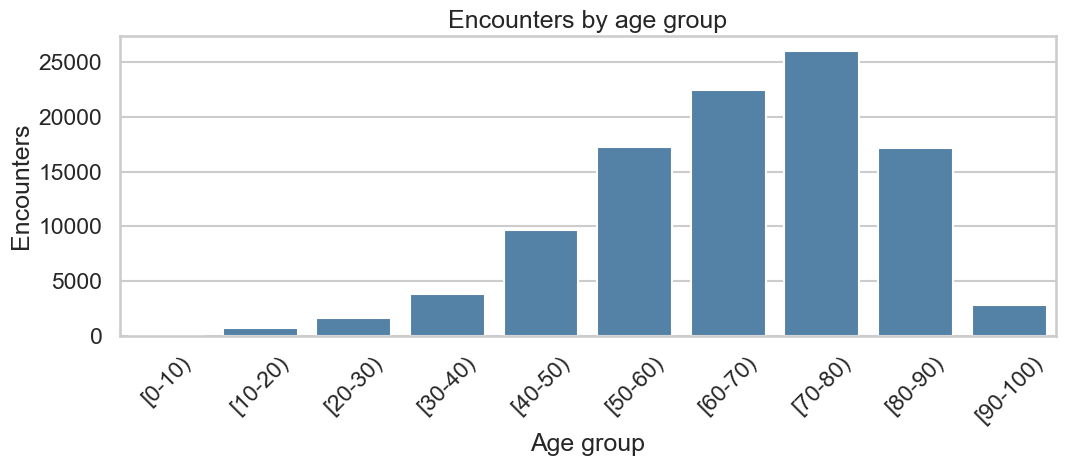

In [5]:
# Age is recorded as 10-year bins, not continuous. Order matters for plotting.
age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)",
]

print("Age distribution:")
print(df["age"].value_counts().reindex(age_order))

fig, ax = plt.subplots(figsize=(11, 5))
sns.countplot(data=df, x="age", order=age_order, ax=ax, color="steelblue")
ax.set_title("Encounters by age group")
ax.set_xlabel("Age group")
ax.set_ylabel("Encounters")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

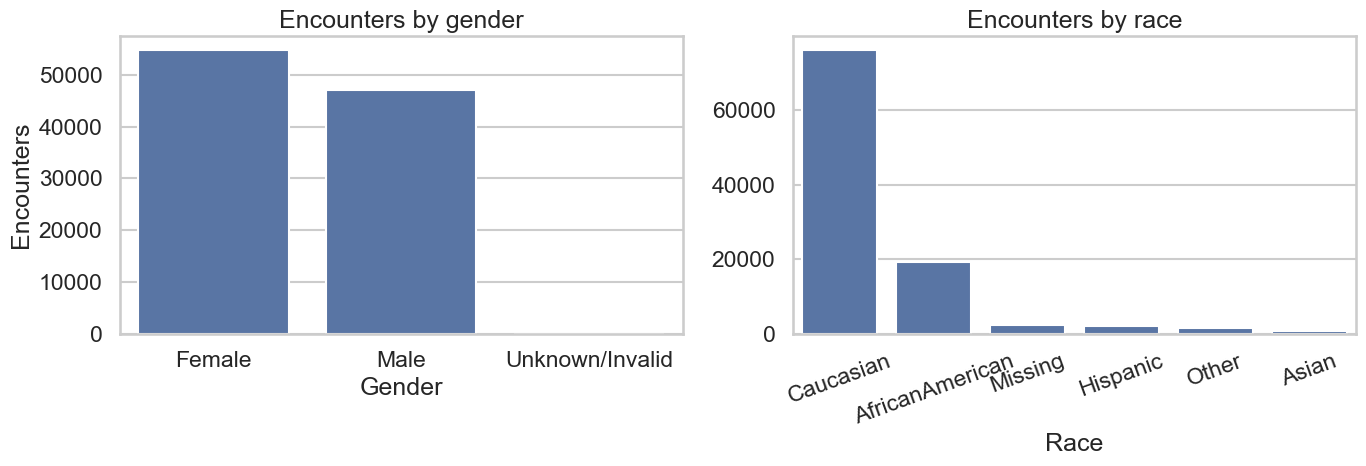


Gender:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

Race:
race
Caucasian          76099
AfricanAmerican    19210
Missing             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender
sns.countplot(data=df, x="gender", ax=axes[0],
              order=df["gender"].value_counts().index)
axes[0].set_title("Encounters by gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Encounters")

# Race — fillna so missing shows up as its own bar
race_data = df["race"].fillna("Missing")
sns.countplot(x=race_data, ax=axes[1],
              order=race_data.value_counts().index)
axes[1].set_title("Encounters by race")
axes[1].set_xlabel("Race")
axes[1].set_ylabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("\nGender:")
print(df["gender"].value_counts())
print("\nRace:")
print(race_data.value_counts())

          readm_rate_pct  n_encounters
age                                   
[0-10)              1.86           161
[10-20)             5.79           691
[20-30)            14.24          1657
[30-40)            11.23          3775
[40-50)            10.60          9685
[50-60)             9.67         17256
[60-70)            11.13         22483
[70-80)            11.77         26068
[80-90)            12.08         17197
[90-100)           11.10          2793


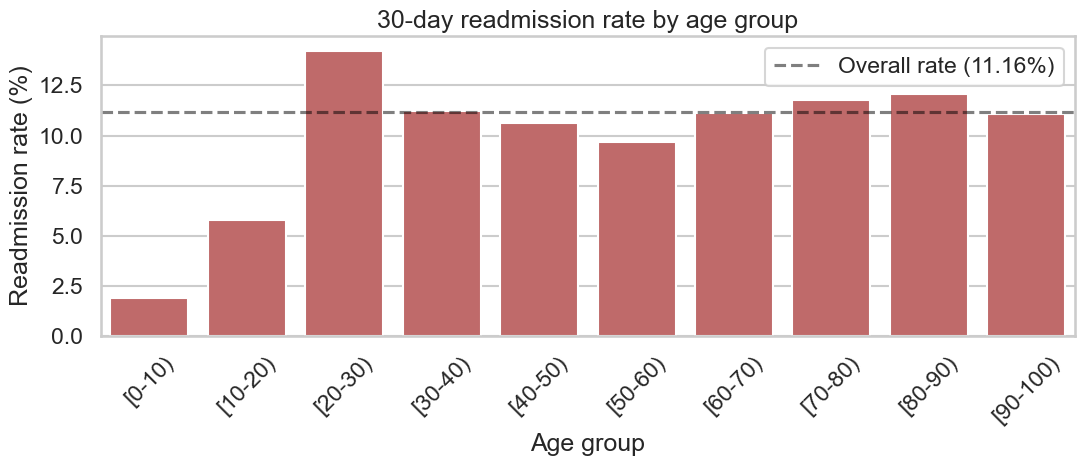

In [7]:
# Binarize target for easier aggregation: 1 if <30, else 0
df["readm_30"] = (df["readmitted"] == "<30").astype(int)

# Readmission rate by age group
readm_by_age = df.groupby("age", observed=True)["readm_30"].agg(["mean", "count"])
readm_by_age["mean"] = readm_by_age["mean"] * 100  # to %
readm_by_age = readm_by_age.reindex(age_order)
readm_by_age.columns = ["readm_rate_pct", "n_encounters"]
print(readm_by_age.round(2))

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=readm_by_age.index, y=readm_by_age["readm_rate_pct"],
            color="indianred", ax=ax)
ax.axhline(11.16, color="black", linestyle="--", alpha=0.5,
           label="Overall rate (11.16%)")
ax.set_title("30-day readmission rate by age group")
ax.set_xlabel("Age group")
ax.set_ylabel("Readmission rate (%)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Age and readmission — a bimodal pattern

The relationship between age and 30-day readmission is **not monotonic**. Two clinically distinct peaks emerge:

**Peak 1 — Young adults `[20-30)`: 14.24%** (the highest rate in the dataset, above any geriatric group).

This counterintuitive finding is consistent with the known clinical profile of young-adult diabetes admissions:
- Predominance of **type 1 diabetes** (insulin-dependent, prone to acute decompensation)
- Higher rates of **DKA** (diabetic ketoacidosis), which is often recurrent
- Lower medication adherence in this demographic — competing life priorities, transition gap from pediatric to adult care, insulin cost
- Less stable chronic disease compared to older T2D patients

**Peak 2 — Older adults `[70-90)`: 11.77%–12.08%**

Driven by the expected mechanisms: multimorbidity, polypharmacy, frailty, reduced physiological reserve, and post-discharge functional decline.

**Drop in `[90-100)` (11.10%)** likely reflects survivor bias and a different care paradigm (palliative orientation in nonagenarian admissions).

**Implication for modeling:** age should not be modeled as a linear predictor. Either keep the original age-group categories as a categorical feature, or consider a non-linear transformation. A simple linear `age_numeric` would average across both peaks and lose this signal entirely.

time_in_hospital — descriptive stats:
count    101766.00
mean          4.40
std           2.99
min           1.00
25%           2.00
50%           4.00
75%           6.00
max          14.00
Name: time_in_hospital, dtype: float64


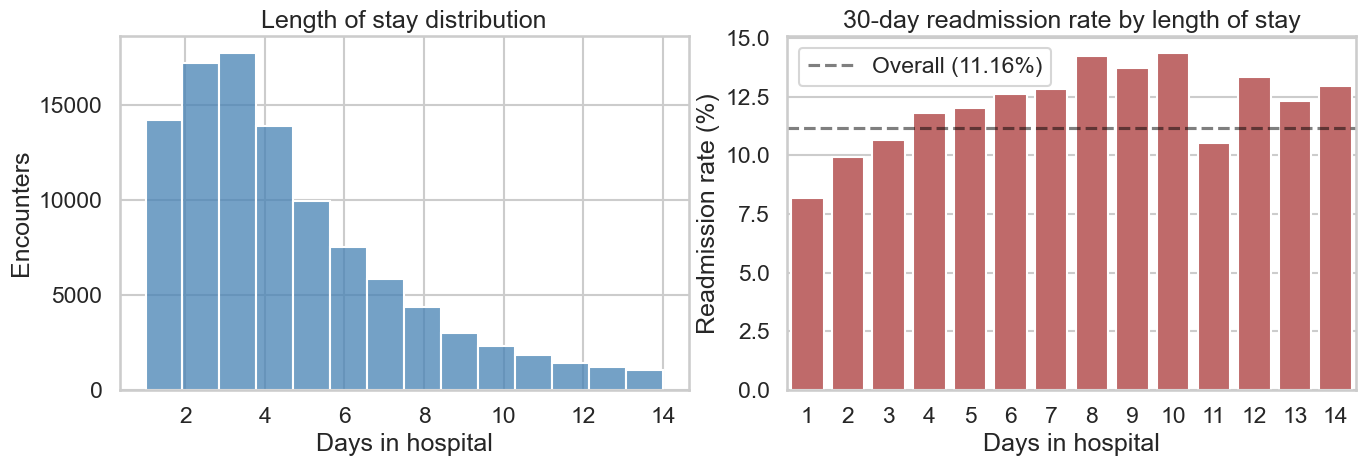

In [8]:
# time_in_hospital: integer days, from admission to discharge
print("time_in_hospital — descriptive stats:")
print(df["time_in_hospital"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
sns.histplot(data=df, x="time_in_hospital", bins=14, ax=axes[0], color="steelblue")
axes[0].set_title("Length of stay distribution")
axes[0].set_xlabel("Days in hospital")
axes[0].set_ylabel("Encounters")

# Readmission rate by length of stay
los_readm = df.groupby("time_in_hospital")["readm_30"].agg(["mean", "count"])
los_readm["mean"] *= 100
sns.barplot(x=los_readm.index, y=los_readm["mean"], color="indianred", ax=axes[1])
axes[1].axhline(11.16, color="black", linestyle="--", alpha=0.5,
                label="Overall (11.16%)")
axes[1].set_title("30-day readmission rate by length of stay")
axes[1].set_xlabel("Days in hospital")
axes[1].set_ylabel("Readmission rate (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

number_diagnoses — descriptive stats:
count    101766.00
mean          7.42
std           1.93
min           1.00
25%           6.00
50%           8.00
75%           9.00
max          16.00
Name: number_diagnoses, dtype: float64


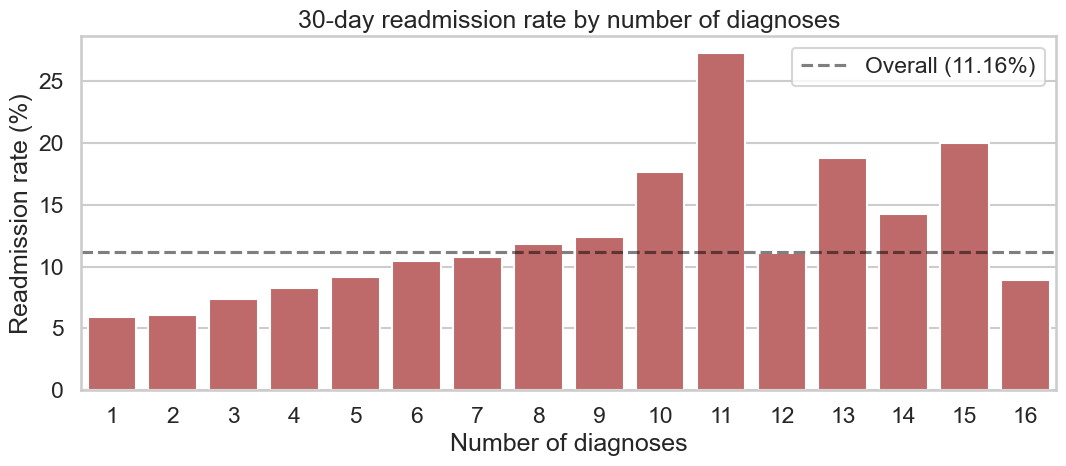


Distribution of number_diagnoses:
number_diagnoses
1       219
2      1023
3      2835
4      5537
5     11393
6     10161
7     10393
8     10616
9     49474
10       17
11       11
12        9
13       16
14        7
15       10
16       45
Name: count, dtype: int64


In [9]:
# number_diagnoses: total number of diagnoses entered for the encounter.
# Higher = more comorbidities = sicker patient.
print("number_diagnoses — descriptive stats:")
print(df["number_diagnoses"].describe().round(2))

ndiag_readm = df.groupby("number_diagnoses")["readm_30"].agg(["mean", "count"])
ndiag_readm["mean"] *= 100

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=ndiag_readm.index, y=ndiag_readm["mean"], color="indianred", ax=ax)
ax.axhline(11.16, color="black", linestyle="--", alpha=0.5, label="Overall (11.16%)")
ax.set_title("30-day readmission rate by number of diagnoses")
ax.set_xlabel("Number of diagnoses")
ax.set_ylabel("Readmission rate (%)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nDistribution of number_diagnoses:")
print(df["number_diagnoses"].value_counts().sort_index())

A1Cresult distribution (including missing as category):
A1Cresult
Not measured    84748
>8               8216
Norm             4990
>7               3812
Name: count, dtype: int64

As percentage:
A1Cresult
Not measured    83.28
>8               8.07
Norm             4.90
>7               3.75
Name: proportion, dtype: float64

Readmission rate by A1C status:
              readm_rate_pct      n
a1c_status                         
Not measured           11.42  84748
Norm                    9.66   4990
>7                     10.05   3812
>8                      9.87   8216


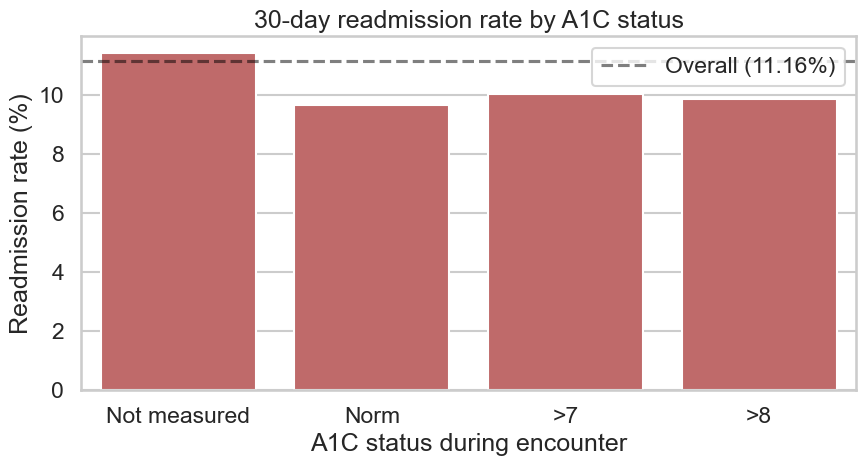

In [10]:
# A1Cresult: 83% missing. Treat "Not measured" as its own category and
# compare readmission rates across all four levels.
a1c_status = df["A1Cresult"].fillna("Not measured")
print("A1Cresult distribution (including missing as category):")
print(a1c_status.value_counts())
print("\nAs percentage:")
print((a1c_status.value_counts(normalize=True) * 100).round(2))

# Readmission rate by A1C status
a1c_readm = (
    df.assign(a1c_status=a1c_status)
      .groupby("a1c_status")["readm_30"]
      .agg(["mean", "count"])
)
a1c_readm["mean"] *= 100
a1c_readm.columns = ["readm_rate_pct", "n"]

# Order: Not measured, Norm, >7, >8
order = ["Not measured", "Norm", ">7", ">8"]
a1c_readm = a1c_readm.reindex(order)
print("\nReadmission rate by A1C status:")
print(a1c_readm.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=a1c_readm.index, y=a1c_readm["readm_rate_pct"],
            color="indianred", ax=ax)
ax.axhline(11.16, color="black", linestyle="--", alpha=0.5,
           label="Overall (11.16%)")
ax.set_title("30-day readmission rate by A1C status")
ax.set_xlabel("A1C status during encounter")
ax.set_ylabel("Readmission rate (%)")
ax.legend()
plt.tight_layout()
plt.show()

### A1C measurement as a signal of care quality

The most clinically rich finding of the EDA so far. Although `A1Cresult` is missing in 83% of encounters, this missingness is **not random** — it carries information about how the diabetes was managed during the index admission.

Observed 30-day readmission rates by A1C status:

| A1C status | Readmission rate | n |
|---|---|---|
| Not measured | 11.42% | 84,748 |
| Norm | 9.66% | 4,990 |
| >7 | 10.05% | 3,812 |
| >8 | 9.87% | 8,216 |

Patients whose A1C was measured — **regardless of the value** — show a 1.5–1.8 percentage point lower readmission rate than patients whose A1C was not measured. The mechanism is not biochemical; it is behavioral. Ordering the A1C is a marker of an inpatient team actively engaging with the patient's diabetes:

- Reviewing the antidiabetic regimen
- Adjusting insulin dosing
- Documenting glycemic control for handoff
- Likely also providing diabetes education at discharge

When the A1C is not ordered, the encounter was probably driven by a different clinical question (pneumonia, fracture, CHF exacerbation) and the diabetes was managed reactively or not at all.

This is **MNAR** (Missing Not At Random): the absence itself encodes information about the outcome.

**Calibrating the effect size:** in this bivariate view the gap is modest (~1.5–1.8 pp, or roughly a 15% relative risk reduction). In multivariate models that adjust for age, comorbidity burden, and specialty (as in Strack et al., 2014), the effect typically appears stronger because confounders are controlled for. We will revisit this with SHAP in Notebook 04.

**Implications for feature engineering:**

- Treat `A1Cresult` missingness as its own category (`"Not measured"`) rather than imputing
- Engineer a binary feature `a1c_measured` (1 if any value, 0 otherwise) — likely a stronger predictor than the A1C value itself
- Apply the same logic to `max_glu_serum` (94% missing) — to be verified

**Reference:** Strack B, DeShazo JP, Gennings C, Olmo JL, Ventura S, Cios KJ, Clore JN. "Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records." *BioMed Research International*, 2014.

                readm_rate_pct      n
admission_type                       
Emergency                11.52  53990
Elective                 10.39  18869
Urgent                   11.18  18480
NULL                     11.08   5291
Not Available            10.34   4785
Not Mapped                8.44    320
Trauma Center             0.00     21
Newborn                  10.00     10


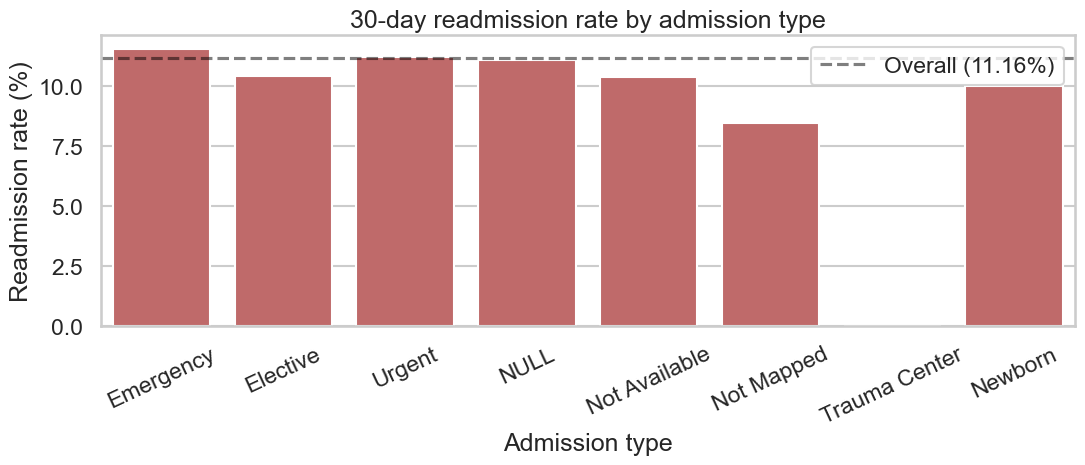

In [11]:
# Use the id_maps loaded earlier to translate numeric IDs to descriptions
admission_type_map = id_maps["admission_type_id"]

df["admission_type"] = df["admission_type_id"].map(admission_type_map)

admit_readm = (
    df.groupby("admission_type")["readm_30"]
      .agg(["mean", "count"])
      .sort_values("count", ascending=False)
)
admit_readm["mean"] *= 100
admit_readm.columns = ["readm_rate_pct", "n"]
print(admit_readm.round(2))

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=admit_readm.index, y=admit_readm["readm_rate_pct"],
            color="indianred", ax=ax,
            order=admit_readm.index)
ax.axhline(11.16, color="black", linestyle="--", alpha=0.5, label="Overall (11.16%)")
ax.set_title("30-day readmission rate by admission type")
ax.set_xlabel("Admission type")
ax.set_ylabel("Readmission rate (%)")
ax.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [12]:
# discharge_disposition_id: identify encounters that ended in death or
# hospice care — these patients cannot readmit and must be excluded
# from the modeling cohort (Strack et al., 2014, applies the same filter).

# IDs corresponding to death or terminal care
EXPIRED_OR_HOSPICE = [11, 13, 14, 19, 20, 21]

# Map ID to description for inspection
disposition_map = id_maps["discharge_disposition_id"]
to_exclude = df[df["discharge_disposition_id"].isin(EXPIRED_OR_HOSPICE)].copy()
to_exclude["description"] = to_exclude["discharge_disposition_id"].map(disposition_map)

print("Encounters to exclude (death or hospice):")
print(to_exclude["description"].value_counts())
print(f"\nTotal to exclude: {len(to_exclude):,} ({len(to_exclude)/len(df)*100:.2f}%)")
print(f"Cohort remaining after exclusion: {len(df) - len(to_exclude):,}")

# Verify these patients indeed have zero readmissions (sanity check)
print(f"\nReadmissions among excluded encounters: {to_exclude['readm_30'].sum()}")

Encounters to exclude (death or hospice):
description
Expired                                                   1642
Hospice / home                                             399
Hospice / medical facility                                 372
Expired at home. Medicaid only, hospice.                     8
Expired in a medical facility. Medicaid only, hospice.       2
Name: count, dtype: int64

Total to exclude: 2,423 (2.38%)
Cohort remaining after exclusion: 99,343

Readmissions among excluded encounters: 43


In [13]:
# Investigate the 43 readmissions among "excluded" encounters.
# Hypothesis: they all come from hospice (not Expired) categories.
diagnostic = (
    df[df["discharge_disposition_id"].isin(EXPIRED_OR_HOSPICE)]
    .assign(description=lambda d: d["discharge_disposition_id"].map(disposition_map))
    .groupby("description")
    .agg(
        n_encounters=("readm_30", "size"),
        n_readmissions=("readm_30", "sum"),
    )
    .assign(readm_rate_pct=lambda d: (d["n_readmissions"] / d["n_encounters"] * 100).round(2))
)
print(diagnostic)

                                                    n_encounters  \
description                                                        
Expired                                                     1642   
Expired at home. Medicaid only, hospice.                       8   
Expired in a medical facility. Medicaid only, h...             2   
Hospice / home                                               399   
Hospice / medical facility                                   372   

                                                    n_readmissions  \
description                                                          
Expired                                                          0   
Expired at home. Medicaid only, hospice.                         0   
Expired in a medical facility. Medicaid only, h...               0   
Hospice / home                                                  19   
Hospice / medical facility                                      24   

                                

### Verifying the exclusion criteria — data integrity check

A targeted check confirmed that **zero readmissions occur in any of the "Expired" categories** (1,652 encounters total). This validates dataset integrity — no encounter is simultaneously coded as in-hospital death and 30-day readmission.

The 43 readmissions among the excluded set come entirely from the two **Hospice** categories (`Hospice / home` and `Hospice / medical facility`):

- These patients did not die during the index admission but were discharged with a terminal-care orientation
- A small fraction (~5–6%) re-enter the hospital, plausibly due to hospice withdrawal or treatable acute complications

**Decision:** all 6 categories remain excluded from the modeling cohort. Hospice patients have a fundamentally different care trajectory and the readmission-prevention framing does not apply to them clinically. Including them would dilute the signal we are trying to learn.

Final excluded cohort: 2,423 encounters (2.38%). Modeling cohort: 99,343 encounters.

---

## Summary — findings and decisions feeding into Notebook 02 (Cleaning & Feature Engineering)

### Dataset

- 101,766 encounters, 50 variables
- Binary target: `readmitted == "<30"` (positive class = 11.16%, imbalanced)
- Missing-value code: `?` (decoded to NaN)

### Clinical findings

1. **Age and readmission are non-monotonic.** Young adults `[20-30)` show the highest readmission rate (14.24%), driven by type-1 diabetes physiology, DKA, and adherence patterns. Older adults `[70-90)` show a secondary peak (~12%) driven by multimorbidity and frailty. Age should not be modeled linearly.
2. **A1C measurement is a care-quality signal.** Encounters where A1C was measured (regardless of value) have ~1.5–1.8 pp lower 30-day readmission than encounters where it was not. This is MNAR — the act of ordering the test reflects active diabetes management during the admission.
3. **Multimorbidity matters.** Readmission rate rises with `number_diagnoses`, but the variable is capped at 9 by the UB-04 billing form, which collapses a heterogeneous high-comorbidity tail.
4. **Length of stay correlates with readmission** — longer stays proxy disease severity and complexity.
5. **Admission type matters, modestly.** Emergency/Urgent admissions readmit slightly more than Elective (~1 pp gap), with much of the signal likely absorbed by age and comorbidity.

### Decisions for Notebook 02

**Cohort definition:**
- Exclude 2,423 encounters with discharge disposition `Expired` (11), `Hospice / home` (13), `Hospice / medical facility` (14), `Expired at home — hospice` (19), `Expired in medical facility — hospice` (20), `Expired, place unknown — hospice` (21). These patients cannot or should not be modeled for readmission prevention. Final modeling cohort: 99,343 encounters.
- Consider deduplicating by `patient_nbr` (keep only first encounter per patient) to avoid leakage between train and test splits.

**Drop:**
- `weight` (96.86% missing)
- `examide`, `citoglipton` (zero variance — single value across all rows)
- `encounter_id` (identifier, not predictive)

**Treat missing as category:**
- `A1Cresult` → 4 levels including "Not measured"
- `max_glu_serum` → 4 levels including "Not measured"
- `medical_specialty` → "Unknown"
- `payer_code` → "Unknown"
- `admission_type_id`: consolidate `NULL`, `Not Available`, `Not Mapped` into a single `"Unknown"` category

**Engineer:**
- `a1c_measured` (binary, 1 if A1C ordered)
- `glu_measured` (binary, 1 if glucose ordered)
- ICD-9 grouping: collapse `diag_1`, `diag_2`, `diag_3` (~700 unique codes each) into clinical chapters (cardiovascular, endocrine, respiratory, etc.)
- `n_meds_changed`: count of antidiabetic medications with status "Up" or "Down"
- `total_visits_prior`: `number_outpatient + number_emergency + number_inpatient`

**Encode:**
- `age` group as ordered categorical (keep the 10-year bins; do not collapse into a single linear feature)
- All other categoricals: one-hot or target encoding (decide based on cardinality)

**Target:**
- Binarize `readmitted` to `1 if "<30" else 0`

### Reference

Strack B, DeShazo JP, Gennings C, Olmo JL, Ventura S, Cios KJ, Clore JN. "Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records." *BioMed Research International*, 2014.